# МАНГА

<img src="https://sun9-65.userapi.com/impg/N4y2cxlL7PauAs82tBNFOUAiNctFICWDy4Mbiw/Jiz1fb7NLWU.jpg?size=1080x1080&quality=95&sign=df2786058624d9ccac3ede4d5d056e2f&type=album" width="500" height="500" />


In [ ]:
# Установка необходимых библиотек
!pip install ultralytics
!pip install scikit-learn
!pip install opencv-python-headless
!pip install matplotlib
!pip install pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.4 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import random
import shutil
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# 1. Монтируем Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2. Разархивируем файлы
zip_path = '/content/drive/MyDrive/Base.zip'
extract_path = '/content/Base'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Архив распакован")
else:
    print("Файл Labeling.zip не найден в /content/drive/MyDrive/")

Архив распакован


In [ ]:
# 3. Пути к данным
images_dir = os.path.join(extract_path, 'images')
labels_dir = os.path.join(extract_path, 'labels')
dataset_dir = '/content/dataset'

if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

In [ ]:
# 4. Копируем изображения и разметку в единую структуру
image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpeg', '.jpg', '.png'))]

for img_file in image_files:
    # Копируем изображение
    src_img = os.path.join(images_dir, img_file)
    dst_img = os.path.join(dataset_dir, img_file)
    shutil.copy2(src_img, dst_img)

    # Копируем соответствующий txt файл
    txt_file = os.path.splitext(img_file)[0] + '.txt'
    src_txt = os.path.join(labels_dir, txt_file)
    dst_txt = os.path.join(dataset_dir, txt_file)
    if os.path.exists(src_txt):
        shutil.copy2(src_txt, dst_txt)

print(f"Скопировано {len(image_files)} изображений и соответствующих txt файлов")

Скопировано 670 изображений и соответствующих txt файлов


In [ ]:
# 5. Разбиваем на train и val (80/20)
all_files = [f for f in os.listdir(dataset_dir) if f.endswith(('.jpeg', '.jpg', '.png'))]
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

# Создаем папки для YOLO
for split in ['train', 'val']:
    os.makedirs(os.path.join(dataset_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, split, 'labels'), exist_ok=True)

# Перемещаем файлы
for img_file in train_files:
    shutil.move(os.path.join(dataset_dir, img_file),
                os.path.join(dataset_dir, 'train', 'images', img_file))
    txt_file = os.path.splitext(img_file)[0] + '.txt'
    if os.path.exists(os.path.join(dataset_dir, txt_file)):
        shutil.move(os.path.join(dataset_dir, txt_file),
                    os.path.join(dataset_dir, 'train', 'labels', txt_file))

for img_file in val_files:
    shutil.move(os.path.join(dataset_dir, img_file),
                os.path.join(dataset_dir, 'val', 'images', img_file))
    txt_file = os.path.splitext(img_file)[0] + '.txt'
    if os.path.exists(os.path.join(dataset_dir, txt_file)):
        shutil.move(os.path.join(dataset_dir, txt_file),
                    os.path.join(dataset_dir, 'val', 'labels', txt_file))

print(f"Обучающая выборка: {len(train_files)} изображений")
print(f"Валидационная выборка: {len(val_files)} изображений")

Обучающая выборка: 536 изображений
Валидационная выборка: 134 изображений


In [ ]:
# 6. Создаем data.yaml
yaml_content = f"""
path: {dataset_dir}
train: train/images
val: val/images

nc: 2
names: ['bubbles', 'text']
"""

with open(os.path.join(dataset_dir, 'data.yaml'), 'w') as f:
    f.write(yaml_content)

print("data.yaml создан")

data.yaml создан


In [ ]:
# 7. Проверяем GPU
import torch
print(f" CUDA доступен: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")
    print(f" GPU память: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# 8. ОБУЧЕНИЕ НА GPU
model = YOLO('yolov8n.pt')

results = model.train(
    data=os.path.join(dataset_dir, 'data.yaml'),
    epochs=80,
    imgsz=640,
    batch=32,
    device=0,  # Используем GPU (0 - первая видеокарта)
    workers=8,  # Больше рабочих процессов для GPU
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    copy_paste=0.0,
    project='yolo',
    name='bubbles_text',
    exist_ok=True,
    patience=50,  # Ранняя остановка при отсутствии улучшений
    save=True,
    save_period=20,  # Сохранять чекпоинт каждые 20 эпох
    verbose=True
)

print(" Обучение завершено!")

 CUDA доступен: True
 GPU: Tesla T4
 GPU память: 14.56 GB
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bubbles_text, nbs=64, nms=False

In [ ]:
import os
import shutil

# путь к модели
best_model_path = '/content/runs/detect/yolo/bubbles_text/weights/best.pt'
drive_best_model = '/content/drive/MyDrive/best_yolo_model.pt'

if os.path.exists(best_model_path):
    shutil.copy2(best_model_path, drive_best_model)
    print(f" Лучшая модель сохранена в {drive_best_model}")
    print(f" Размер: {os.path.getsize(best_model_path) / (1024*1024):.2f} MB")
else:
    print(f" Модель не найдена по пути: {best_model_path}")

    # Поиск в альтернативных местах
    print("\n Ищем модель в других местах...")
    alt_paths = [
        '/content/runs/detect/yolo/bubbles_text/weights/best.pt',
        '/content/runs/detect/bubbles_text/weights/best.pt',
        '/content/runs/detect/yolo/bubbles_text/weights/last.pt',
        '/content/best_V.pt'
    ]

    for path in alt_paths:
        if os.path.exists(path):
            print(f" Найдена модель: {path}")
            shutil.copy2(path, drive_best_model)
            print(f" Модель скопирована в {drive_best_model}")
            break

 Лучшая модель сохранена в /content/drive/MyDrive/best_yolo_model.pt
 Размер: 5.93 MB


In [ ]:
# 9. Загружаем лучшую модель для инференса
best_model = YOLO(drive_best_model)


image 1/1 /content/dataset/val/images/172.jpeg: 640x544 1 bubbles, 1 text, 40.3ms
Speed: 2.4ms preprocess, 40.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 544)

image 1/1 /content/dataset/val/images/561.jpg: 512x640 1 bubbles, 12 texts, 43.8ms
Speed: 2.6ms preprocess, 43.8ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /content/dataset/val/images/210.jpeg: 640x640 1 bubbles, 1 text, 7.8ms
Speed: 2.7ms preprocess, 7.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/dataset/val/images/524.jpg: 640x480 10 bubbless, 10 texts, 39.5ms
Speed: 2.0ms preprocess, 39.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/dataset/val/images/007.jpeg: 640x448 14 bubbless, 15 texts, 39.3ms
Speed: 2.2ms preprocess, 39.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/dataset/val/images/564.jpg: 512x640 17 bubbless, 29 texts, 6.7ms
Speed: 2.

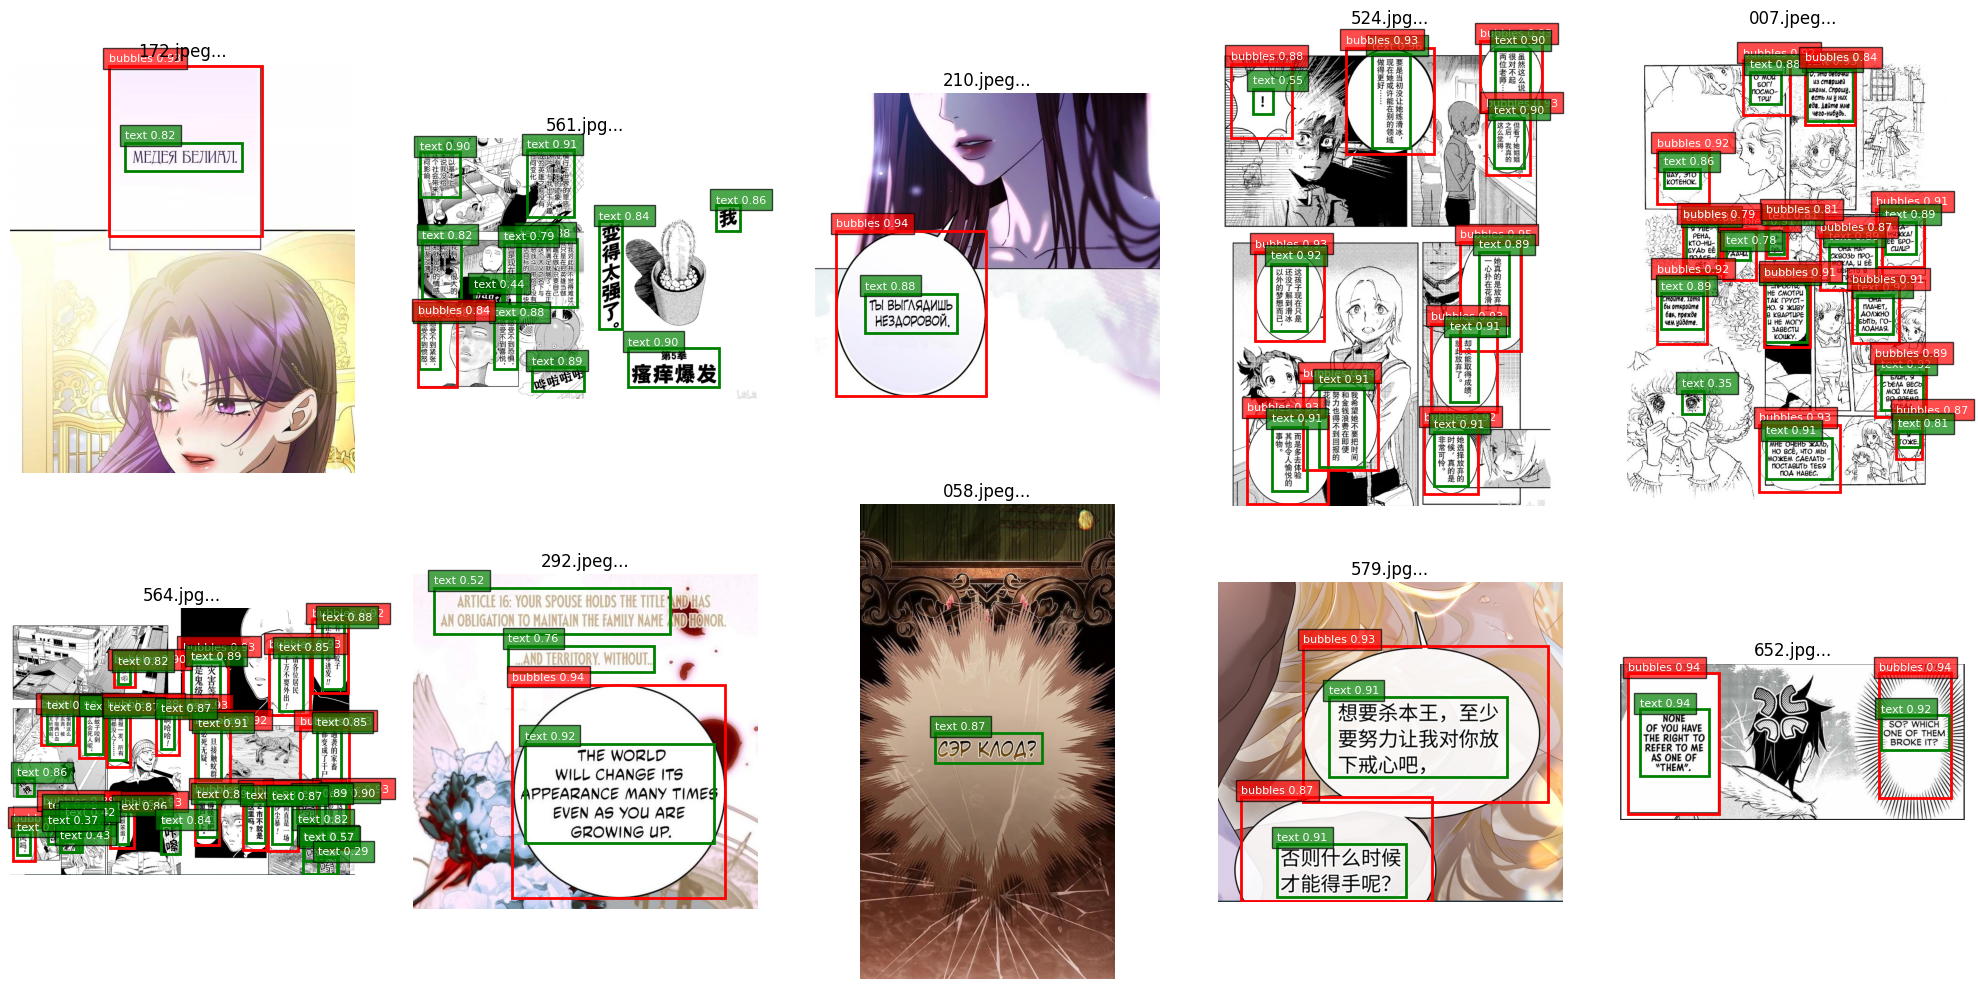

Обработка завершена! Результаты сохранены в Google Drive


In [ ]:
# 10. Показываем 10 случайных изображений с предсказаниями
val_images_path = os.path.join(dataset_dir, 'val', 'images')
val_images = [f for f in os.listdir(val_images_path) if f.endswith(('.jpeg', '.jpg', '.png'))]

if len(val_images) >= 10:
    random_images = random.sample(val_images, 10)
else:
    random_images = val_images

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, img_name in enumerate(random_images):
    img_path = os.path.join(val_images_path, img_name)

    # Предсказание
    results = best_model(img_path)

    # Отображение результата
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f'{img_name[:15]}...')

    # Рисуем боксы
    if results[0].boxes is not None:
        for box in results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            cls = int(box.cls[0].cpu().numpy())
            label = 'bubbles' if cls == 0 else 'text'

            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                    linewidth=2, edgecolor='r' if cls==0 else 'g',
                                    facecolor='none')
            axes[idx].add_patch(rect)
            axes[idx].text(x1, y1-10, f'{label} {conf:.2f}',
                          color='white', fontsize=8,
                          bbox=dict(facecolor='red' if cls==0 else 'green', alpha=0.7))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/predictions_sample.png', dpi=150)
plt.show()

print("Обработка завершена! Результаты сохранены в Google Drive")